# Conformal Verification

## 0. Prepare workspace

### Imports

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from batch_generation import generate_random_batch
from plot_functions import plot_pb_trajectories, plot_nonconformity_scores
from evaluation_setup import EvaluationConfig, prepare_evaluation_context

import nonconformity
import plot_functions

### Prepare evaluation context

In [ ]:
checkpoint_path_standard = 'ren_standard_checkpoint.pt'
checkpoint_path_cvar = 'ren_pinball_checkpoint.pt'
device = 'cpu'

horizon = 300
num_test_samples = 500
x0_std = 0.2
noise_std = 0.0
n_agents = 1

config = EvaluationConfig()

# Load both models
ctx = prepare_evaluation_context(
    checkpoint_path=checkpoint_path_standard,
    device=device,
    config=config
)
ctx_cvar = prepare_evaluation_context(
    checkpoint_path=checkpoint_path_cvar,
    device=device,
    config=config
)

# Extract standard model
eval_system = ctx['eval_system']
metric = ctx['metric']
x_target = ctx['x_target']
obs_centers = ctx['obs_centers']
obs_sigmas = ctx['obs_sigmas']
pb_loop_standard = eval_system['pb_loop']

# Extract CVaR model
pb_loop_cvar = ctx_cvar['eval_system']['pb_loop']

print('Evaluation context is ready.')
print(f"REN dims: {ctx['dims']}")
print(f"Standard model - Missing keys: {list(ctx['load_result'].missing_keys)}")
print(f"Standard model - Unexpected keys: {list(ctx['load_result'].unexpected_keys)}")
print(f"CVaR model - Missing keys: {list(ctx_cvar['load_result'].missing_keys)}")
print(f"CVaR model - Unexpected keys: {list(ctx_cvar['load_result'].unexpected_keys)}")

Evaluation context is ready.
REN dims: {'dim_in': 4, 'dim_out': 2, 'dim_internal': 4, 'dim_nl': 4}
Standard model - Missing keys: ['x', 'init_x']
Standard model - Unexpected keys: []
CVaR model - Missing keys: ['x', 'init_x']
CVaR model - Unexpected keys: []


## 1. Conditional conformal verification pipeline

### Set up conformal parameters

In [4]:
# Non-conformity score (supported: "pb_loss", "pb_collision")
non_conformity_score = "pb_loss"

# Conditional vs marginal
conditional_verification = True

# Probability thresholds and certification dataset size
alpha = 0.05       # w/r draw of calibration data
delta = 0.05            # P w/r nonconformity score violation
m_cert = 1000           # Size of certification dataset
test_dataset_size = 1000
nb_experiments = 100           

#Calculate the shift in alpha for conditional certificates
if conditional_verification:
    epsilon_cert = np.sqrt(np.log(2 / delta) / (2 * m_cert))
else:
    epsilon_cert = 0

# Shift alpha
alpha_conditional = alpha - epsilon_cert

# Set seed for reproducibility
seed = 2
torch.manual_seed(seed)
np.random.seed(seed)

### Sample calibration dataset

In [5]:
# Sample noise realizations for calibration
calibration_w = generate_random_batch(batch_size=m_cert, horizon=horizon, n_agents=n_agents,
                                    x0_std=x0_std, noise_std=noise_std, device=device)

# Unroll trajectories with BOTH models on identical calibration batch
traj_std, traj_cvar = {}, {}
pb_loop_standard.eval()
pb_loop_cvar.eval()
with torch.no_grad():
    traj_std["x"], traj_std["u"], traj_std["w_hat"] = pb_loop_standard.run(calibration_w)
    traj_cvar["x"], traj_cvar["u"], traj_cvar["w_hat"] = pb_loop_cvar.run(calibration_w)

### Find the conditional threshold of the non-conformity score on the calibration set

In [6]:
# Build non-conformity scorer from selector (reusable for both models)
scorer = nonconformity.build_scorer(
    non_conformity_score,
    pb_loss_config=nonconformity.PBLossConfig(
        x_target=x_target,
        q=ctx["Q"],
        r=ctx["R"],
        alpha_obs=config.alpha_obs,
        obs_centers=obs_centers,
        obs_sigmas=obs_sigmas,
        n_agents=n_agents,
    ),
)

# Compute calibration thresholds for both models on their identical calibration data
calibration_result_std = nonconformity.calibrate_nonconformity(
    trajectories=traj_std,
    scorer=scorer,
    alpha=alpha_conditional,
    finite_sample=True,
)
calibration_result_cvar = nonconformity.calibrate_nonconformity(
    trajectories=traj_cvar,
    scorer=scorer,
    alpha=alpha_conditional,
    finite_sample=True,
)

print(f"Standard model - Conditional conformal threshold: {calibration_result_std.threshold.item():.6f}")
print(f"CVaR model     - Conditional conformal threshold: {calibration_result_cvar.threshold.item():.6f}")

Standard model - Conditional conformal threshold: 2.115349
CVaR model     - Conditional conformal threshold: 2.115349


### Empirically verify the calibration threshold on a test set

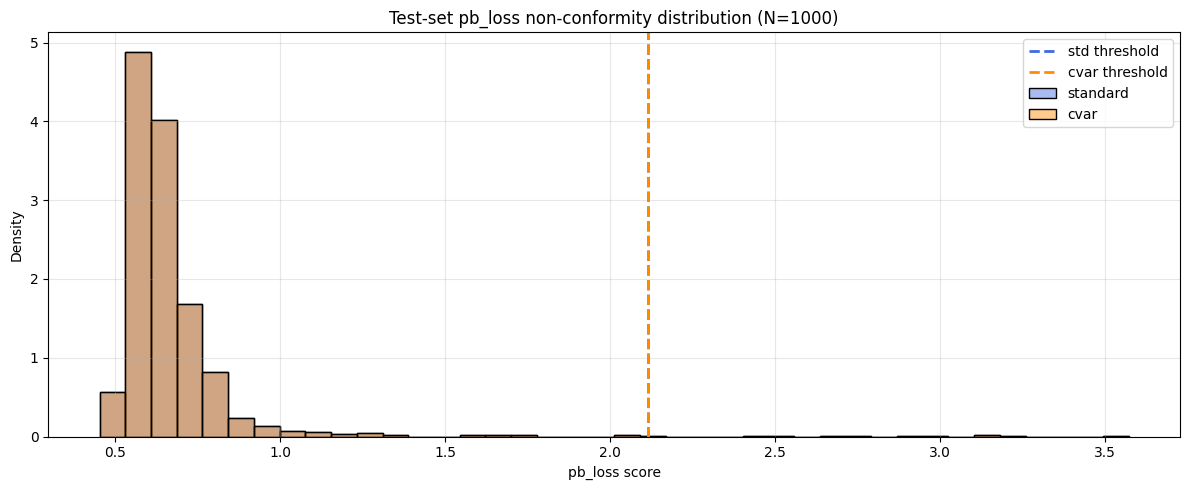

Standard model: fraction(score < threshold) = 0.9900
CVaR model:     fraction(score < threshold) = 0.9900
Reference 1-alpha: 0.9500


In [7]:
# Sample an independent test set for NC evaluation
nc_test_w = generate_random_batch(
    batch_size=test_dataset_size,
    horizon=horizon,
    n_agents=n_agents,
    x0_std=x0_std,
    noise_std=noise_std,
    device=device,
)

# Unroll test trajectories with BOTH models on identical test batch
nc_test_traj_std, nc_test_traj_cvar = {}, {}
pb_loop_standard.eval()
pb_loop_cvar.eval()
with torch.no_grad():
    nc_test_traj_std["x"], nc_test_traj_std["u"], nc_test_traj_std["w_hat"] = pb_loop_standard.run(nc_test_w)
    nc_test_traj_cvar["x"], nc_test_traj_cvar["u"], nc_test_traj_cvar["w_hat"] = pb_loop_cvar.run(nc_test_w)

# Compute non-conformity scores for both models
test_nc_scores_std = nonconformity.compute_nonconformity_scores(nc_test_traj_std, scorer)
test_nc_scores_cvar = nonconformity.compute_nonconformity_scores(nc_test_traj_cvar, scorer)

fraction_std = (test_nc_scores_std < calibration_result_std.threshold).float().mean().item()
fraction_cvar = (test_nc_scores_cvar < calibration_result_cvar.threshold).float().mean().item()

# Plot test non-conformity score distributions with thresholds
scores_std_np = test_nc_scores_std.detach().cpu().numpy()
scores_cvar_np = test_nc_scores_cvar.detach().cpu().numpy()

plt.figure(figsize=(12, 5))
sns.histplot(scores_std_np, bins=40, stat="density", color="royalblue", alpha=0.45, label="standard")
sns.histplot(scores_cvar_np, bins=40, stat="density", color="darkorange", alpha=0.45, label="cvar")
plt.axvline(calibration_result_std.threshold.item(), color="royalblue", linestyle="--", linewidth=2, label="std threshold")
plt.axvline(calibration_result_cvar.threshold.item(), color="darkorange", linestyle="--", linewidth=2, label="cvar threshold")
plt.title(f"Test-set {non_conformity_score} non-conformity distribution (N={test_dataset_size})")
plt.xlabel(f"{non_conformity_score} score")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Standard model: fraction(score < threshold) = {fraction_std:.4f}")
print(f"CVaR model:     fraction(score < threshold) = {fraction_cvar:.4f}")
print(f"Reference 1-alpha: {1.0 - alpha:.4f}")

### Repeated experimentation for empirical estimation of delta

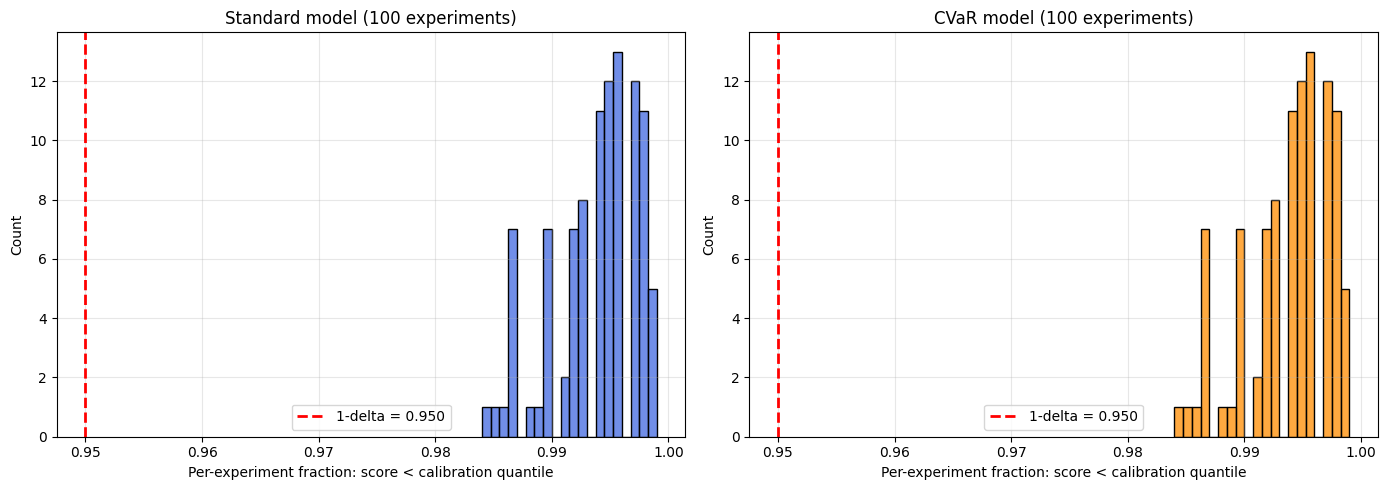

Standard model - Empirical P(fraction >= 1-delta): 1.0000
CVaR model     - Empirical P(fraction >= 1-delta): 1.0000


In [8]:
fractions_below_quantile_std = []
fractions_below_quantile_cvar = []

pb_loop_standard.eval()
pb_loop_cvar.eval()
with torch.no_grad():
    for _ in range(nb_experiments):
        # 1) Calibration split for this experiment
        calibration_w_i = generate_random_batch(
            batch_size=m_cert,
            horizon=horizon,
            n_agents=n_agents,
            x0_std=x0_std,
            noise_std=noise_std,
            device=device,
        )
        traj_cal_std_i, traj_cal_cvar_i = {}, {}
        traj_cal_std_i["x"], traj_cal_std_i["u"], traj_cal_std_i["w_hat"] = pb_loop_standard.run(calibration_w_i)
        traj_cal_cvar_i["x"], traj_cal_cvar_i["u"], traj_cal_cvar_i["w_hat"] = pb_loop_cvar.run(calibration_w_i)

        calibration_result_std_i = nonconformity.calibrate_nonconformity(
            trajectories=traj_cal_std_i,
            scorer=scorer,
            alpha=alpha_conditional,
            finite_sample=True,
        )
        calibration_result_cvar_i = nonconformity.calibrate_nonconformity(
            trajectories=traj_cal_cvar_i,
            scorer=scorer,
            alpha=alpha_conditional,
            finite_sample=True,
        )

        # 2) Independent test split for this experiment
        test_w_i = generate_random_batch(
            batch_size=test_dataset_size,
            horizon=horizon,
            n_agents=n_agents,
            x0_std=x0_std,
            noise_std=noise_std,
            device=device,
        )
        traj_test_std_i, traj_test_cvar_i = {}, {}
        traj_test_std_i["x"], traj_test_std_i["u"], traj_test_std_i["w_hat"] = pb_loop_standard.run(test_w_i)
        traj_test_cvar_i["x"], traj_test_cvar_i["u"], traj_test_cvar_i["w_hat"] = pb_loop_cvar.run(test_w_i)

        test_scores_std_i = nonconformity.compute_nonconformity_scores(traj_test_std_i, scorer)
        test_scores_cvar_i = nonconformity.compute_nonconformity_scores(traj_test_cvar_i, scorer)

        fraction_std_i = (test_scores_std_i < calibration_result_std_i.threshold).float().mean().item()
        fraction_cvar_i = (test_scores_cvar_i < calibration_result_cvar_i.threshold).float().mean().item()
        fractions_below_quantile_std.append(fraction_std_i)
        fractions_below_quantile_cvar.append(fraction_cvar_i)

fractions_std = np.asarray(fractions_below_quantile_std)
fractions_cvar = np.asarray(fractions_below_quantile_cvar)

# Empirical estimate: P( fraction >= 1 - delta )
empirical_prob_std = np.mean(fractions_std >= (1.0 - delta))
empirical_prob_cvar = np.mean(fractions_cvar >= (1.0 - delta))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(fractions_std, bins=20, kde=False, color="royalblue", ax=axes[0])
axes[0].axvline(1.0 - delta, color="red", linestyle="--", linewidth=2, label=f"1-delta = {1.0 - delta:.3f}")
axes[0].set_xlabel("Per-experiment fraction: score < calibration quantile")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Standard model ({nb_experiments} experiments)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sns.histplot(fractions_cvar, bins=20, kde=False, color="darkorange", ax=axes[1])
axes[1].axvline(1.0 - delta, color="red", linestyle="--", linewidth=2, label=f"1-delta = {1.0 - delta:.3f}")
axes[1].set_xlabel("Per-experiment fraction: score < calibration quantile")
axes[1].set_ylabel("Count")
axes[1].set_title(f"CVaR model ({nb_experiments} experiments)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Standard model - Empirical P(fraction >= 1-delta): {empirical_prob_std:.4f}")
print(f"CVaR model     - Empirical P(fraction >= 1-delta): {empirical_prob_cvar:.4f}")